# ECG Signal Processing & Biometric Identification

This notebook processes ECG signals from two known subjects (**Ali** and **Mohamed**) and one **unknown test signal**.
We extract both **fiducial** (QRS-based) and **non-fiducial** (DWT, AC+DCT) features, export them, and then identify the test signal.

---

## 0 — Import Libraries

All dependencies are listed in `requirements.txt`. Install them with:
```
pip install -r requirements.txt
```

We use the following libraries:
- **NumPy** — numerical computation (arrays, linear algebra)
- **Pandas** — tabular data manipulation and Excel export
- **SciPy** — signal processing (filtering, peak detection, DCT)
- **PyWavelets (pywt)** — Discrete Wavelet Transform
- **Matplotlib** — visualization
- **openpyxl** — Excel file engine for pandas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import dct                # Discrete Cosine Transform
from scipy.stats import pearsonr         # for distance metric

import pywt                              # Discrete Wavelet Transform

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 0.1 — Load the ECG Signals

Each text file contains **two tab-separated columns** (Lead I and Lead II) with
**23 040 samples**. We will use **Lead II** (column index 1) because it provides
the clearest QRS complex for fiducial point detection.

In [2]:
# ── Load raw signals ──────────────────────────────────────────────────
# Each file has two columns separated by a tab.
# Column 0 = Lead I, Column 1 = Lead II.
# We select Lead II (index 1) for analysis.

ecg_ali_raw      = np.loadtxt('ECG_Ali.txt',      dtype=float)
ecg_mohamed_raw  = np.loadtxt('ECG_Mohamed.txt',  dtype=float)
ecg_test_raw     = np.loadtxt('Test signal.txt',  dtype=float)

# Use Lead II (second column)
ecg_ali     = ecg_ali_raw[:, 1]
ecg_mohamed = ecg_mohamed_raw[:, 1]
ecg_test    = ecg_test_raw[:, 1]

print(f"ECG_Ali     : {ecg_ali.shape[0]} samples")
print(f"ECG_Mohamed : {ecg_mohamed.shape[0]} samples")
print(f"Test signal : {ecg_test.shape[0]} samples")

ECG_Ali     : 23040 samples
ECG_Mohamed : 23040 samples
Test signal : 23040 samples


### 0.2 — Preprocessing: Band-Pass Filter

Raw ECG contains **baseline wander** (low-frequency drift < 0.5 Hz) and
**high-frequency noise** (muscle artifacts, power-line interference).

We apply a **Butterworth band-pass filter (0.5 – 40 Hz)** to keep only the
physiologically relevant components of the ECG signal.

We assume a **sampling frequency of 360 Hz** (standard for many ECG databases
like MIT-BIH).

In [3]:
# ── Preprocessing parameters ─────────────────────────────────────────
FS = 360          # Sampling frequency in Hz
LOWCUT  = 0.5     # High-pass cutoff  → removes baseline wander
HIGHCUT = 40.0    # Low-pass cutoff   → removes high-frequency noise
ORDER   = 4       # Filter order (4th-order Butterworth)

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """
    Apply a zero-phase Butterworth band-pass filter.
    
    Parameters
    ----------
    signal  : 1-D array of raw ECG samples
    lowcut  : lower cutoff frequency (Hz)
    highcut : upper cutoff frequency (Hz)
    fs      : sampling frequency (Hz)
    order   : filter order
    
    Returns
    -------
    Filtered signal (same length as input).
    """
    nyq = 0.5 * fs                                    # Nyquist frequency
    low  = lowcut  / nyq                              # Normalised lower cutoff
    high = highcut / nyq                              # Normalised upper cutoff
    b, a = butter(order, [low, high], btype='band')   # Design filter
    return filtfilt(b, a, signal)                     # Zero-phase filtering

# Apply the band-pass filter to all three signals
ecg_ali_filt     = bandpass_filter(ecg_ali,     LOWCUT, HIGHCUT, FS, ORDER)
ecg_mohamed_filt = bandpass_filter(ecg_mohamed, LOWCUT, HIGHCUT, FS, ORDER)
ecg_test_filt    = bandpass_filter(ecg_test,    LOWCUT, HIGHCUT, FS, ORDER)

print("Band-pass filtering complete.")

Band-pass filtering complete.


### 0.3 — Quick Visualization of the Filtered Signals

Let us plot a **2-second window** of each filtered signal to visually confirm
that the QRS complexes are clearly visible.

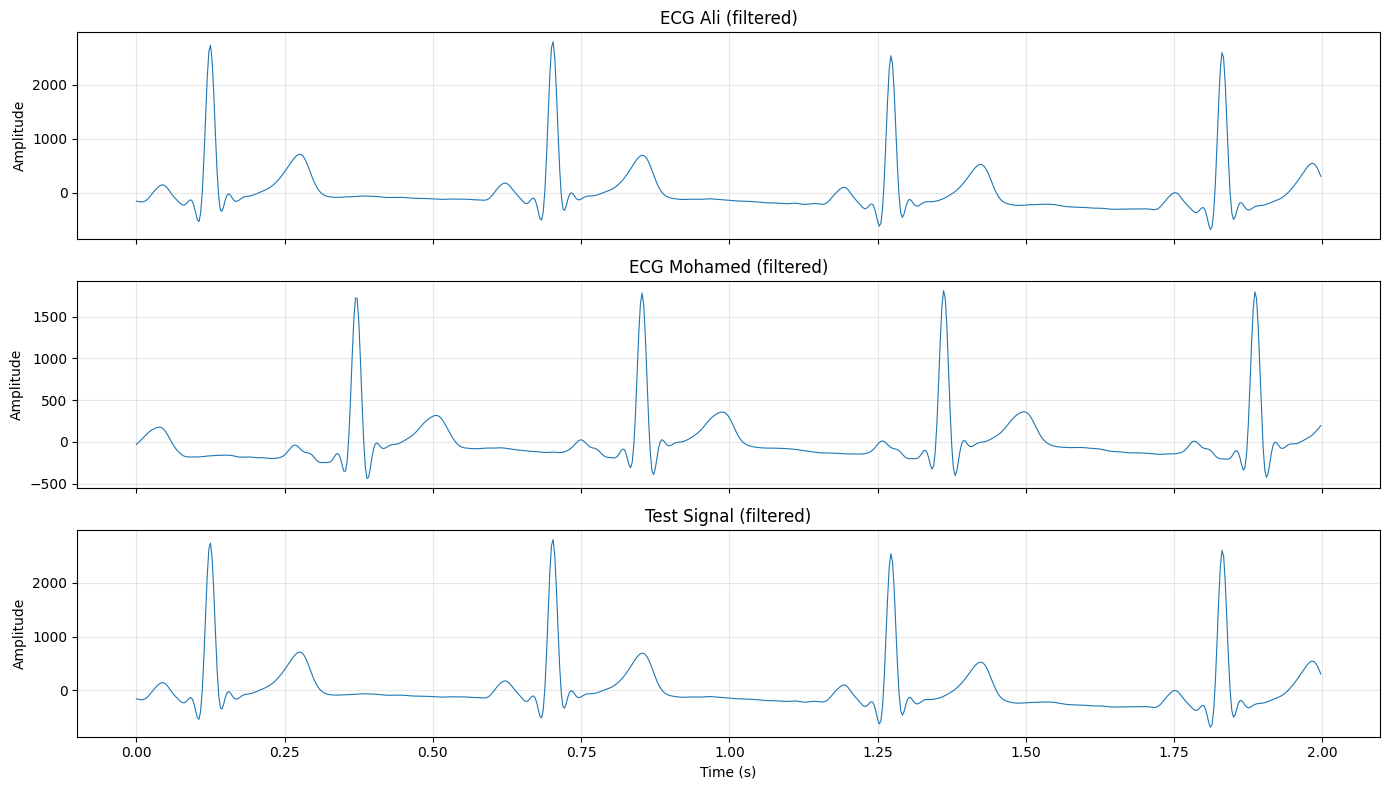

In [4]:
# ── Plot the first 2 seconds (720 samples at 360 Hz) ─────────────────
window = int(2 * FS)  # 720 samples
time_axis = np.arange(window) / FS  # time in seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

signals = [ecg_ali_filt, ecg_mohamed_filt, ecg_test_filt]
titles  = ['ECG Ali (filtered)', 'ECG Mohamed (filtered)', 'Test Signal (filtered)']

for ax, sig, title in zip(axes, signals, titles):
    ax.plot(time_axis, sig[:window], linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

---
# Step 1 — Fiducial Feature Detection (QRS Complex)

## What are fiducial features?

**Fiducial features** are measurements derived from identifiable landmark points
(fiducial points) on the ECG waveform. The **QRS complex** has three key points:

| Point | Description |
|-------|-------------|
| **Q** | The first downward deflection before the R peak |
| **R** | The tallest upward peak in the QRS complex |
| **S** | The first downward deflection after the R peak |

From these three points we compute:
- **QR interval** — time (in samples or seconds) from Q to R
- **RS interval** — time from R to S
- **QS slope**    — amplitude change / time change from Q to S

### Detection strategy
1. Detect **R peaks** using `scipy.signal.find_peaks` with a minimum distance
   constraint (R-R interval > 200 ms → ~72 samples at 360 Hz).
2. For each R peak, search a small **window before** it to find the **Q point**
   (local minimum).
3. Similarly, search a small **window after** R to find the **S point**
   (local minimum).

In [5]:
def detect_qrs_points(signal, fs=360):
    """
    Detect Q, R, S fiducial points in an ECG signal.
    
    Algorithm
    ---------
    1. Find R peaks using find_peaks with:
       - minimum distance = 0.2 s × fs  (ensures no two R peaks within 200 ms)
       - height = mean + 0.5 × std       (adaptive threshold)
    2. For each R peak:
       - Q = local minimum in the window [R - 0.08s, R]
       - S = local minimum in the window [R, R + 0.08s]
    
    Parameters
    ----------
    signal : 1-D numpy array (filtered ECG)
    fs     : sampling frequency (Hz)
    
    Returns
    -------
    q_indices, r_indices, s_indices : arrays of sample indices
    """
    # ── Step 1: Detect R peaks ────────────────────────────────────────
    min_distance = int(0.2 * fs)          # At least 200 ms between R peaks
    threshold    = np.mean(signal) + 0.5 * np.std(signal)  # Adaptive height threshold
    
    r_peaks, _ = find_peaks(signal,
                            distance=min_distance,
                            height=threshold)
    
    # ── Step 2: Find Q and S around each R ───────────────────────────
    q_search_window = int(0.08 * fs)      # 80 ms before R  (~29 samples)
    s_search_window = int(0.08 * fs)      # 80 ms after R   (~29 samples)
    
    q_points = []
    s_points = []
    valid_r  = []
    
    for r in r_peaks:
        # --- Q point: local min in [r - window, r] ---
        q_start = max(0, r - q_search_window)
        q_end   = r
        if q_start >= q_end:
            continue
        q_idx = q_start + np.argmin(signal[q_start:q_end])
        
        # --- S point: local min in [r, r + window] ---
        s_start = r
        s_end   = min(len(signal), r + s_search_window)
        if s_start >= s_end:
            continue
        s_idx = s_start + np.argmin(signal[s_start:s_end])
        
        q_points.append(q_idx)
        s_points.append(s_idx)
        valid_r.append(r)
    
    return np.array(q_points), np.array(valid_r), np.array(s_points)

In [6]:
# ── Detect QRS points for all three signals ──────────────────────────
q_ali, r_ali, s_ali          = detect_qrs_points(ecg_ali_filt, FS)
q_mohamed, r_mohamed, s_mohamed = detect_qrs_points(ecg_mohamed_filt, FS)
q_test, r_test, s_test       = detect_qrs_points(ecg_test_filt, FS)

print(f"ECG_Ali     → {len(r_ali)} beats detected")
print(f"ECG_Mohamed → {len(r_mohamed)} beats detected")
print(f"Test signal → {len(r_test)} beats detected")

ECG_Ali     → 116 beats detected
ECG_Mohamed → 133 beats detected
Test signal → 116 beats detected


### 1.2 — Visualize Detected QRS Points (first 3 seconds)

We overlay Q (green), R (red), and S (blue) markers on the filtered signal
to verify that the detection is correct.

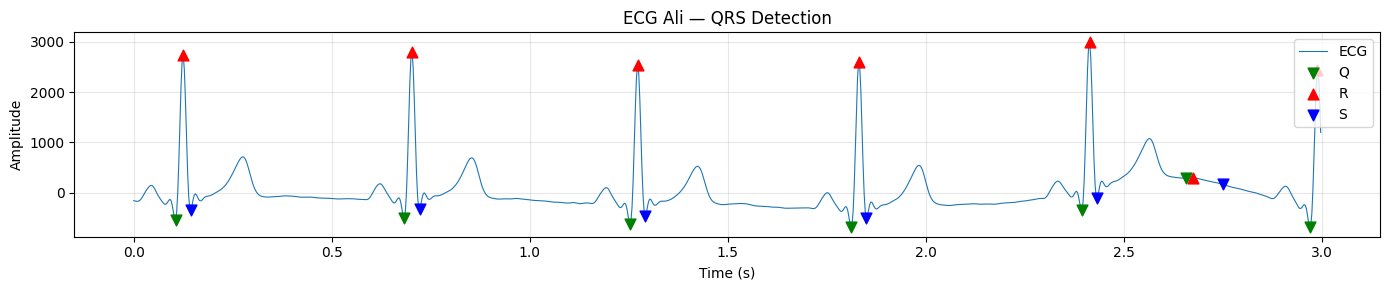

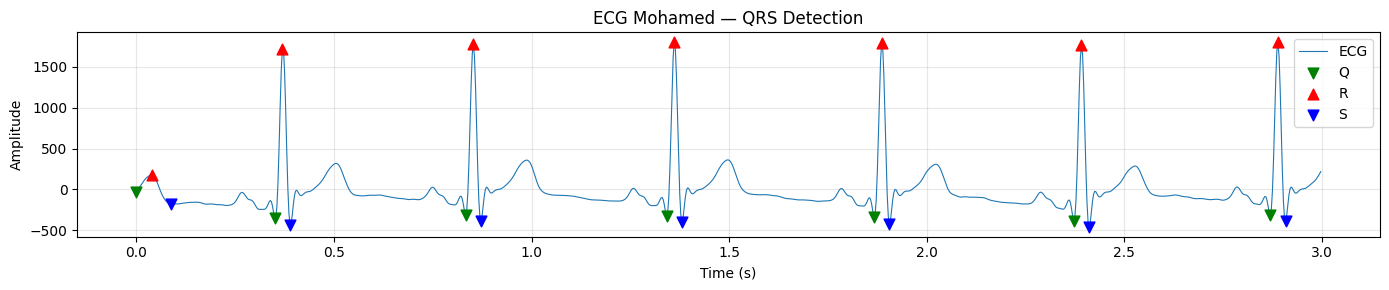

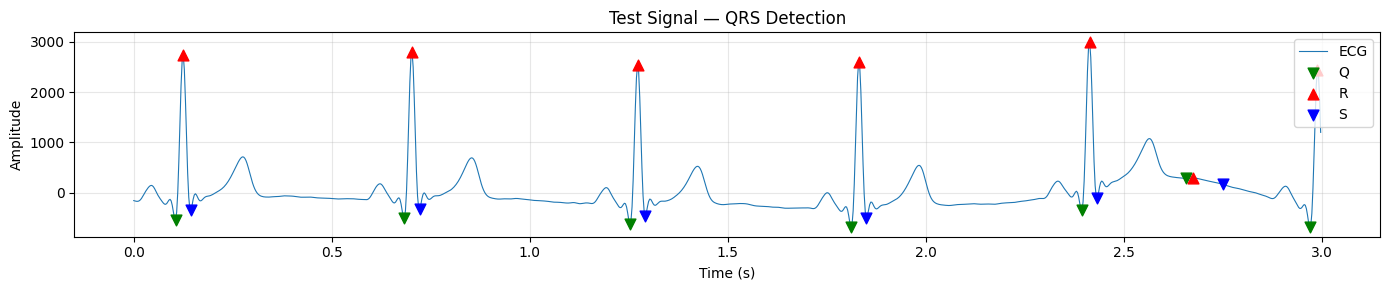

In [7]:
def plot_qrs(signal, q, r, s, title, fs=360, duration=3):
    """
    Plot the ECG signal with Q, R, S markers for the first `duration` seconds.
    """
    n = int(duration * fs)
    t = np.arange(n) / fs
    
    plt.figure(figsize=(14, 3))
    plt.plot(t, signal[:n], linewidth=0.8, label='ECG')
    
    # Filter points that fall within the display window
    mask_q = q < n
    mask_r = r < n
    mask_s = s < n
    
    plt.scatter(q[mask_q] / fs, signal[q[mask_q]], color='green',  marker='v', s=60, zorder=5, label='Q')
    plt.scatter(r[mask_r] / fs, signal[r[mask_r]], color='red',    marker='^', s=60, zorder=5, label='R')
    plt.scatter(s[mask_s] / fs, signal[s[mask_s]], color='blue',   marker='v', s=60, zorder=5, label='S')
    
    plt.title(title, fontsize=12)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_qrs(ecg_ali_filt,     q_ali,     r_ali,     s_ali,     'ECG Ali — QRS Detection')
plot_qrs(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, 'ECG Mohamed — QRS Detection')
plot_qrs(ecg_test_filt,    q_test,    r_test,    s_test,    'Test Signal — QRS Detection')

### 1.3 — Calculate Fiducial Features

From the detected Q, R, S points, we calculate **per-beat** features:

| Feature | Formula | Meaning |
|---------|---------|--------|
| **QR interval** | `R_index − Q_index` | Duration of the upstroke (samples) |
| **RS interval** | `S_index − R_index` | Duration of the downstroke (samples) |
| **QS slope** | `(Amp_S − Amp_Q) / (S_index − Q_index)` | Average slope across the full QRS |

We then summarise each signal's features by their **mean** and **standard deviation**,
giving us a compact "fingerprint" for each person.

In [8]:
def compute_fiducial_features(signal, q, r, s, fs=360):
    """
    Compute per-beat fiducial features and return summary statistics.
    
    Returns
    -------
    dict : contains mean and std of QR_interval, RS_interval, QS_slope
    per_beat : DataFrame with per-beat values
    """
    # Per-beat measurements
    qr_intervals = r - q                       # QR interval in samples
    rs_intervals = s - r                       # RS interval in samples
    
    # QS slope = (amplitude at S − amplitude at Q) / (S_index − Q_index)
    qs_slopes = (signal[s] - signal[q]) / (s - q + 1e-9)  # +epsilon avoids /0
    
    per_beat = pd.DataFrame({
        'QR_interval': qr_intervals,
        'RS_interval': rs_intervals,
        'QS_slope':    qs_slopes
    })
    
    # Summary statistics (mean and std)
    summary = {
        'QR_interval_mean': np.mean(qr_intervals),
        'QR_interval_std':  np.std(qr_intervals),
        'RS_interval_mean': np.mean(rs_intervals),
        'RS_interval_std':  np.std(rs_intervals),
        'QS_slope_mean':    np.mean(qs_slopes),
        'QS_slope_std':     np.std(qs_slopes),
    }
    
    return summary, per_beat

In [9]:
# ── Calculate fiducial features for each signal ──────────────────────
fid_ali,     beats_ali     = compute_fiducial_features(ecg_ali_filt,     q_ali,     r_ali,     s_ali,     FS)
fid_mohamed, beats_mohamed = compute_fiducial_features(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, FS)
fid_test,    beats_test    = compute_fiducial_features(ecg_test_filt,    q_test,    r_test,    s_test,    FS)

# Display the summary in a DataFrame
fiducial_df = pd.DataFrame([fid_ali, fid_mohamed, fid_test],
                           index=['ECG_Ali', 'ECG_Mohamed', 'Test_Signal'])

print("=== Fiducial Feature Summary ===")
fiducial_df

=== Fiducial Feature Summary ===


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std
ECG_Ali,7.284483,1.706004,7.379310,3.215413,12.808117,3.141997
ECG_Mohamed,7.067669,0.627628,6.984962,1.003640,-5.398426,1.298667
Test_Signal,7.284483,1.706004,7.379310,3.215413,12.808117,3.141997


---
# Step 2 — Non-Fiducial Feature Extraction

Non-fiducial methods extract features from the **overall morphology** of the
signal rather than from specific landmark points. They are more robust to
noise and easier to compute because they do not require precise point detection.

We use two techniques:
1. **Discrete Wavelet Transform (DWT)** — decomposes the signal into frequency
   sub-bands; we extract statistical features from the coefficients.
2. **Autocorrelation + Discrete Cosine Transform (AC+DCT)** — the autocorrelation
   captures periodicity; DCT compresses it into a compact feature vector.

---

## 2.1 — Discrete Wavelet Transform (DWT)

### How DWT works
DWT splits the signal into **approximation** (low-frequency) and **detail**
(high-frequency) coefficients at multiple levels. We use the **Daubechies-4
(`db4`)** wavelet (commonly used for ECG) with **level 4** decomposition.

From each level's detail coefficients, we extract:
- Mean of absolute values
- Standard deviation
- Energy (sum of squares)

This gives us a **frequency-band feature vector** that characterises the signal.

In [10]:
def extract_dwt_features(signal, wavelet='db4', level=4):
    """
    Extract features from DWT decomposition.
    
    Steps
    -----
    1. Perform multi-level DWT → [cA4, cD4, cD3, cD2, cD1]
       cA4 = level-4 approximation coefficients
       cDn = level-n detail coefficients
    2. For each set of coefficients, compute:
       - mean(|coeff|)  → average magnitude
       - std(coeff)     → spread of the coefficients
       - sum(coeff^2)   → energy of the sub-band
    
    Parameters
    ----------
    signal  : 1-D numpy array
    wavelet : wavelet family (default 'db4')
    level   : decomposition depth
    
    Returns
    -------
    dict : DWT feature dictionary
    """
    # Perform the DWT decomposition
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    # coeffs = [cA_level, cD_level, cD_level-1, ..., cD_1]
    
    features = {}
    names = ['cA4', 'cD4', 'cD3', 'cD2', 'cD1']  # label each level
    
    for name, c in zip(names, coeffs):
        features[f'DWT_{name}_mean_abs'] = np.mean(np.abs(c))   # Average magnitude
        features[f'DWT_{name}_std']      = np.std(c)            # Spread
        features[f'DWT_{name}_energy']   = np.sum(c ** 2)       # Energy
    
    return features

In [11]:
# ── Extract DWT features ─────────────────────────────────────────────
dwt_ali     = extract_dwt_features(ecg_ali_filt)
dwt_mohamed = extract_dwt_features(ecg_mohamed_filt)
dwt_test    = extract_dwt_features(ecg_test_filt)

dwt_df = pd.DataFrame([dwt_ali, dwt_mohamed, dwt_test],
                       index=['ECG_Ali', 'ECG_Mohamed', 'Test_Signal'])

print("=== DWT Feature Summary ===")
dwt_df

=== DWT Feature Summary ===


,DWT_cA4_mean_abs,DWT_cA4_std,DWT_cA4_energy,DWT_cD4_mean_abs,DWT_cD4_std,DWT_cD4_energy,DWT_cD3_mean_abs,DWT_cD3_std,DWT_cD3_energy,DWT_cD2_mean_abs,DWT_cD2_std,DWT_cD2_energy,DWT_cD1_mean_abs,DWT_cD1_std,DWT_cD1_energy
ECG_Ali,1031.212711,1323.203673,2.531755e+09,515.895706,1042.068476,1.570729e+09,207.776081,580.451553,9.723889e+08,41.353495,126.354547,9.204094e+07,3.116344,9.657595,1.074740e+06
ECG_Mohamed,606.143167,784.194839,8.892349e+08,371.447414,746.619816,8.067998e+08,165.575355,436.947623,5.510056e+08,34.316696,94.355991,5.132611e+07,2.526767,6.972924,5.602676e+05
Test_Signal,1031.212711,1323.203673,2.531755e+09,515.895706,1042.068476,1.570729e+09,207.776081,580.451553,9.723889e+08,41.353495,126.354547,9.204094e+07,3.116344,9.657595,1.074740e+06


## 2.2 — Autocorrelation + Discrete Cosine Transform (AC + DCT)

### Why AC + DCT?

1. **Autocorrelation (AC)** measures how similar a signal is to a delayed
   version of itself. For a periodic signal like ECG, the autocorrelation
   shows peaks at multiples of the heart-beat period. This makes it a
   powerful tool for capturing the **rhythmic structure** of the ECG.

2. **DCT** is applied to the autocorrelation vector to **compress** it.
   DCT packs most of the energy into the first few coefficients, so we
   keep only the first **N** coefficients as features. This is similar to
   how JPEG compresses images.

### Steps
1. Compute the full autocorrelation of the signal.
2. Normalise it to [−1, 1].
3. Apply DCT (type II) to the normalised autocorrelation.
4. Keep the first 20 DCT coefficients as features.

In [12]:
def extract_ac_dct_features(signal, n_coeffs=20):
    """
    Extract AC+DCT features from an ECG signal.
    
    Parameters
    ----------
    signal   : 1-D numpy array
    n_coeffs : number of DCT coefficients to retain
    
    Returns
    -------
    dict : AC_DCT features
    """
    # ── Step 1: Compute autocorrelation ───────────────────────────────
    # np.correlate(signal, signal, 'full') gives the raw cross-correlation
    # of the signal with itself. The result has length 2N-1.
    signal_zero_mean = signal - np.mean(signal)        # Remove mean first
    ac_full = np.correlate(signal_zero_mean, signal_zero_mean, mode='full')
    
    # Take only the positive-lag half (length = N)
    ac = ac_full[len(ac_full) // 2:]
    
    # ── Step 2: Normalise to [−1, 1] by dividing by the zero-lag value
    ac_normalised = ac / (ac[0] + 1e-9)  # ac[0] is the signal energy
    
    # ── Step 3: Apply DCT (Type II) ──────────────────────────────────
    ac_dct = dct(ac_normalised, type=2, norm='ortho')
    
    # ── Step 4: Keep first n_coeffs ──────────────────────────────────
    features = {}
    for i in range(n_coeffs):
        features[f'AC_DCT_{i}'] = ac_dct[i]
    
    return features

In [13]:
# ── Extract AC+DCT features ──────────────────────────────────────────
ac_dct_ali     = extract_ac_dct_features(ecg_ali_filt)
ac_dct_mohamed = extract_ac_dct_features(ecg_mohamed_filt)
ac_dct_test    = extract_ac_dct_features(ecg_test_filt)

ac_dct_df = pd.DataFrame([ac_dct_ali, ac_dct_mohamed, ac_dct_test],
                          index=['ECG_Ali', 'ECG_Mohamed', 'Test_Signal'])

print("=== AC+DCT Feature Summary (first 10 shown) ===")
ac_dct_df.iloc[:, :10]

=== AC+DCT Feature Summary (first 10 shown) ===


,AC_DCT_0,AC_DCT_1,AC_DCT_2,AC_DCT_3,AC_DCT_4,AC_DCT_5,AC_DCT_6,AC_DCT_7,AC_DCT_8,AC_DCT_9
ECG_Ali,0.003294,0.004906,0.004853,0.004837,0.004855,0.004834,0.004858,0.004836,0.004863,0.004839
ECG_Mohamed,0.003294,0.005361,0.004813,0.005306,0.004813,0.005302,0.004813,0.005302,0.004813,0.005304
Test_Signal,0.003294,0.004906,0.004853,0.004837,0.004855,0.004834,0.004858,0.004836,0.004863,0.004839


### 2.3 — Combine All Features into a Single Feature Map

We merge the **fiducial features**, **DWT features**, and **AC+DCT features**
into a single DataFrame — the **combined feature map**.

Each row represents a signal (Ali, Mohamed, Test), and each column is a feature.

In [14]:
# ── Merge all feature dictionaries per signal ────────────────────────
def merge_features(*dicts):
    """Merge multiple feature dictionaries into one."""
    merged = {}
    for d in dicts:
        merged.update(d)
    return merged

all_ali     = merge_features(fid_ali,     dwt_ali,     ac_dct_ali)
all_mohamed = merge_features(fid_mohamed, dwt_mohamed, ac_dct_mohamed)
all_test    = merge_features(fid_test,    dwt_test,    ac_dct_test)

# Build the combined feature map DataFrame
feature_map = pd.DataFrame([all_ali, all_mohamed, all_test],
                           index=['ECG_Ali', 'ECG_Mohamed', 'Test_Signal'])

print(f"Combined feature map: {feature_map.shape[0]} signals × {feature_map.shape[1]} features")
feature_map

Combined feature map: 3 signals × 41 features


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std,DWT_cA4_mean_abs,DWT_cA4_std,DWT_cA4_energy,DWT_cD4_mean_abs,...,AC_DCT_10,AC_DCT_11,AC_DCT_12,AC_DCT_13,AC_DCT_14,AC_DCT_15,AC_DCT_16,AC_DCT_17,AC_DCT_18,AC_DCT_19
ECG_Ali,7.284483,1.706004,7.379310,3.215413,12.808117,3.141997,1031.212711,1323.203673,2.531755e+09,515.895706,...,0.004869,0.004844,0.004876,0.004850,0.004886,0.004857,0.004897,0.004866,0.004916,0.004877
ECG_Mohamed,7.067669,0.627628,6.984962,1.003640,-5.398426,1.298667,606.143167,784.194839,8.892349e+08,371.447414,...,0.004813,0.005306,0.004812,0.005308,0.004812,0.005311,0.004812,0.005314,0.004811,0.005318
Test_Signal,7.284483,1.706004,7.379310,3.215413,12.808117,3.141997,1031.212711,1323.203673,2.531755e+09,515.895706,...,0.004869,0.004844,0.004876,0.004850,0.004886,0.004857,0.004897,0.004866,0.004916,0.004877


---
# Step 3 — Export Feature Map to Excel

We save the combined feature map as an Excel file (`.xlsx`).
The file will have:
- **Sheet 1 ("All_Features")**: the full combined feature map
- **Sheet 2 ("Fiducial")**: fiducial features only
- **Sheet 3 ("DWT")**: DWT features only
- **Sheet 4 ("AC_DCT")**: AC+DCT features only

In [15]:
# ── Export to Excel ──────────────────────────────────────────────────
output_file = 'ECG_Feature_Map.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    feature_map.to_excel(writer, sheet_name='All_Features')
    fiducial_df.to_excel(writer, sheet_name='Fiducial')
    dwt_df.to_excel(writer, sheet_name='DWT')
    ac_dct_df.to_excel(writer, sheet_name='AC_DCT')

print(f"Feature map saved to '{output_file}' with 4 sheets.")

Feature map saved to 'ECG_Feature_Map.xlsx' with 4 sheets.


---
# Step 4 — Signal Identification

## Goal
Determine whether the **Test Signal** belongs to **Ali** or **Mohamed** by
comparing their extracted features.

## Strategy

### 4.1 — Select the Most Distinctive Feature
We want to find the **single feature** that best separates Ali from Mohamed.
We measure this by computing the **absolute difference** between Ali and
Mohamed for every feature, normalised by the average magnitude (to avoid
scale bias). The feature with the **largest normalised difference** is the
most distinctive.

### 4.2 — Classify the Test Signal
Using that most-distinctive feature, we compare the test signal's value to
Ali's and Mohamed's values. The **closer match** determines the identity.

### 4.3 — Full-Vector Verification
As extra verification, we also compare **all features at once** using
Euclidean distance.

In [16]:
# ── 4.1 Find the most distinctive feature ────────────────────────────

# Extract feature vectors for Ali and Mohamed (exclude Test)
ali_features     = feature_map.loc['ECG_Ali']
mohamed_features = feature_map.loc['ECG_Mohamed']
test_features    = feature_map.loc['Test_Signal']

# Compute normalised absolute difference for each feature
# Normalisation = |Ali − Mohamed| / (0.5*(|Ali| + |Mohamed|) + epsilon)
abs_diff   = np.abs(ali_features - mohamed_features)
avg_mag    = 0.5 * (np.abs(ali_features) + np.abs(mohamed_features)) + 1e-9
norm_diff  = abs_diff / avg_mag

# Sort by distinctiveness (descending)
distinctiveness = norm_diff.sort_values(ascending=False)

print("=== Top 10 Most Distinctive Features ===")
print(distinctiveness.head(10).to_string())
print()

# The most distinctive feature
best_feature = distinctiveness.index[0]
print(f"Most distinctive feature: '{best_feature}'")
print(f"  Ali     = {ali_features[best_feature]:.6f}")
print(f"  Mohamed = {mohamed_features[best_feature]:.6f}")
print(f"  Test    = {test_features[best_feature]:.6f}")

=== Top 10 Most Distinctive Features ===
QS_slope_mean       2.000000
RS_interval_std     1.048469
DWT_cA4_energy      0.960260
QR_interval_std     0.924204
QS_slope_std        0.830205
DWT_cD4_energy      0.642624
DWT_cD1_energy      0.629322
DWT_cD2_energy      0.567980
DWT_cD3_energy      0.553216
DWT_cA4_mean_abs    0.519215

Most distinctive feature: 'QS_slope_mean'
  Ali     = 12.808117
  Mohamed = -5.398426
  Test    = 12.808117


In [17]:
# ── 4.2 Classify the test signal using the most distinctive feature ──

dist_to_ali     = abs(test_features[best_feature] - ali_features[best_feature])
dist_to_mohamed = abs(test_features[best_feature] - mohamed_features[best_feature])

print(f"Distance to Ali     (feature '{best_feature}'): {dist_to_ali:.6f}")
print(f"Distance to Mohamed (feature '{best_feature}'): {dist_to_mohamed:.6f}")
print()

if dist_to_ali < dist_to_mohamed:
    identity = 'Ali'
else:
    identity = 'Mohamed'

print(f"▶ Based on the most distinctive feature, the Test Signal belongs to: **{identity}**")

Distance to Ali     (feature 'QS_slope_mean'): 0.000000
Distance to Mohamed (feature 'QS_slope_mean'): 18.206543

▶ Based on the most distinctive feature, the Test Signal belongs to: **Ali**


In [18]:
# ── 4.3 Full-vector verification using Euclidean distance ────────────
#
# As a secondary check, we compare the full feature vectors using
# Euclidean distance. This considers ALL features simultaneously.

# Normalise features to zero mean and unit variance (z-score) to prevent
# large-magnitude features from dominating the distance calculation.
mean_vals = feature_map.mean(axis=0)
std_vals  = feature_map.std(axis=0) + 1e-9   # avoid division by zero

ali_norm     = (ali_features     - mean_vals) / std_vals
mohamed_norm = (mohamed_features - mean_vals) / std_vals
test_norm    = (test_features    - mean_vals) / std_vals

# Euclidean distance
eucl_to_ali     = np.sqrt(np.sum((test_norm - ali_norm) ** 2))
eucl_to_mohamed = np.sqrt(np.sum((test_norm - mohamed_norm) ** 2))

print("=== Full-Vector Euclidean Distance ===")
print(f"  Test ↔ Ali     : {eucl_to_ali:.4f}")
print(f"  Test ↔ Mohamed : {eucl_to_mohamed:.4f}")
print()

if eucl_to_ali < eucl_to_mohamed:
    identity_full = 'Ali'
else:
    identity_full = 'Mohamed'

print(f"▶ Full-vector verification confirms: Test Signal belongs to **{identity_full}**")

=== Full-Vector Euclidean Distance ===
  Test ↔ Ali     : 0.0000
  Test ↔ Mohamed : 10.9544

▶ Full-vector verification confirms: Test Signal belongs to **Ali**


### 4.4 — Visualization: Feature Comparison Bar Chart

We visualize the value of the **most distinctive feature** for all three signals
side by side, making it easy to see which reference signal the test signal
matches.

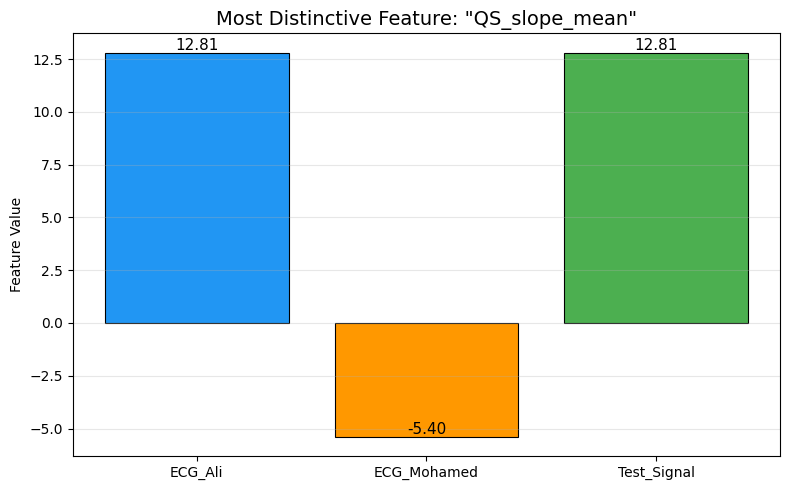

In [19]:
# ── Bar chart comparing the most distinctive feature ─────────────────
labels = ['ECG_Ali', 'ECG_Mohamed', 'Test_Signal']
values = [ali_features[best_feature],
          mohamed_features[best_feature],
          test_features[best_feature]]

colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
plt.title(f'Most Distinctive Feature: "{best_feature}"', fontsize=14)
plt.ylabel('Feature Value')

# Annotate bars with their values
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

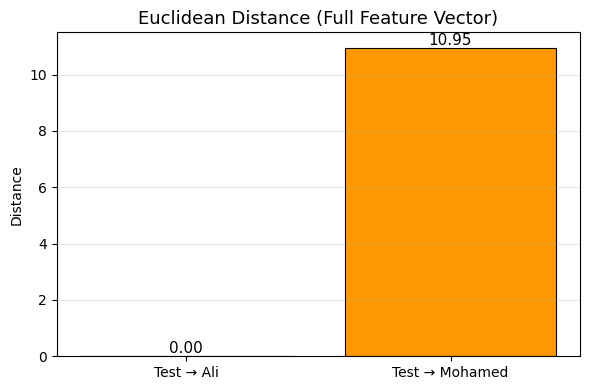

In [20]:
# ── Distance comparison bar chart ────────────────────────────────────
plt.figure(figsize=(6, 4))

dist_labels = ['Test → Ali', 'Test → Mohamed']
dist_values = [eucl_to_ali, eucl_to_mohamed]
dist_colors = ['#2196F3', '#FF9800']

bars = plt.bar(dist_labels, dist_values, color=dist_colors,
               edgecolor='black', linewidth=0.8)
plt.title('Euclidean Distance (Full Feature Vector)', fontsize=13)
plt.ylabel('Distance')

for bar, val in zip(bars, dist_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()